In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split #used to split data
from sklearn.preprocessing import StandardScaler #normalize data
from sklearn.linear_model import LinearRegression #ML model
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import PolynomialFeatures

In [3]:
df = pd.read_csv("BostonHousing.csv")

In [4]:
df.shape

(506, 14)

In [5]:
df.head() #it will show first 5 data

,Crime_rate,zn,indus,chas,nox,rm,Age,Distance,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


Columns:

- CRIM: Per capita crime rate by town
- ZN: Proportion of residential land zoned for lots over 25,000 sq. ft
- INDUS: Proportion of non-retail business acres per town
- CHAS: Charles River dummy variable (1 if tract bounds river; 0 otherwise)
- NOX: Nitric oxide concentration (parts per 10 million)
- RM: Average number of rooms per dwelling
- AGE: Proportion of owner-occupied units built prior to 1940
- DIS: Weighted distances to five Boston employment centers
- RAD: Index of accessibility to radial highways
- TRATIO: Pupil-teacher ratio by town
- B: 1000(Bk — 0.63)², where Bk is the proportion of people of African American descent by town.
- LSTAT: Percentage of lower status of the population
- MEDV: Median value of owner-occupied homes in $1000s

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Crime_rate  506 non-null    float64
 1   zn          506 non-null    float64
 2   indus       506 non-null    float64
 3   chas        506 non-null    int64  
 4   nox         506 non-null    float64
 5   rm          501 non-null    float64
 6   Age         506 non-null    float64
 7   Distance    506 non-null    float64
 8   rad         506 non-null    int64  
 9   tax         506 non-null    int64  
 10  ptratio     506 non-null    float64
 11  b           506 non-null    float64
 12  lstat       506 non-null    float64
 13  medv        506 non-null    float64
dtypes: float64(11), int64(3)
memory usage: 55.5 KB


Handle missing values   

Linear regression cannot handle null values

In [8]:
df["rm"].fillna(df["rm"].mean(), inplace=True) #relacing the null values with mean

In [9]:
df.isnull().sum() #again checking the null values

Crime_rate    0
zn            0
indus         0
chas          0
nox           0
rm            0
Age           0
Distance      0
rad           0
tax           0
ptratio       0
b             0
lstat         0
medv          0
dtype: int64

In [7]:
df.isnull().sum() # check the null values/missing values

Crime_rate    0
zn            0
indus         0
chas          0
nox           0
rm            5
Age           0
Distance      0
rad           0
tax           0
ptratio       0
b             0
lstat         0
medv          0
dtype: int64

In [10]:
df.duplicated().sum() #it will give the no.of duplicated row

0

Target variable = medv as it gives info on the median value of houses we need to predict housing prices

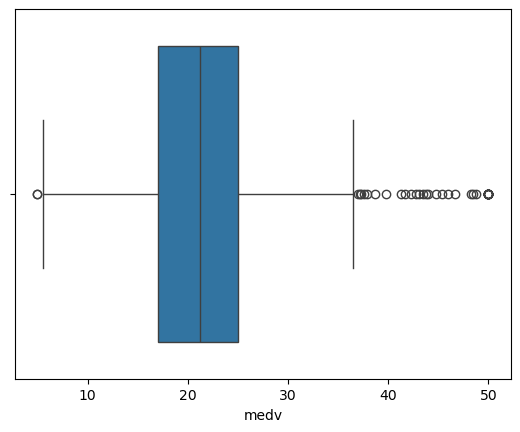

In [15]:
sns.boxplot(x=df["medv"])
plt.show()

In [35]:
df.corr()["medv"].sort_values(ascending=False) #compute corelation between features and house price
#rm → strong positive (more rooms → higher price)
#lstat → strong negative (lower status → lower price)

medv          1.000000
rm            0.701244
zn            0.360445
Distance      0.295424
b             0.271067
chas          0.175260
Age          -0.376955
nox          -0.427321
Crime_rate   -0.433531
tax          -0.474707
indus        -0.483725
ptratio      -0.507188
lstat        -0.820536
Name: medv, dtype: float64

In [33]:
num_cols = df.select_dtypes(include=np.number).columns #select numeric coumns as outlier detect in numeric

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    outliers = df[(df[col] < Q1 - 1.5*IQR) |
                  (df[col] > Q3 + 1.5*IQR)]   #anything outside this range is outlier

    print(col, "outliers:", len(outliers))

Crime_rate outliers: 0
zn outliers: 68
indus outliers: 0
chas outliers: 35
nox outliers: 0
rm outliers: 0
Age outliers: 0
Distance outliers: 0
tax outliers: 0
ptratio outliers: 0
b outliers: 0
lstat outliers: 3
medv outliers: 40


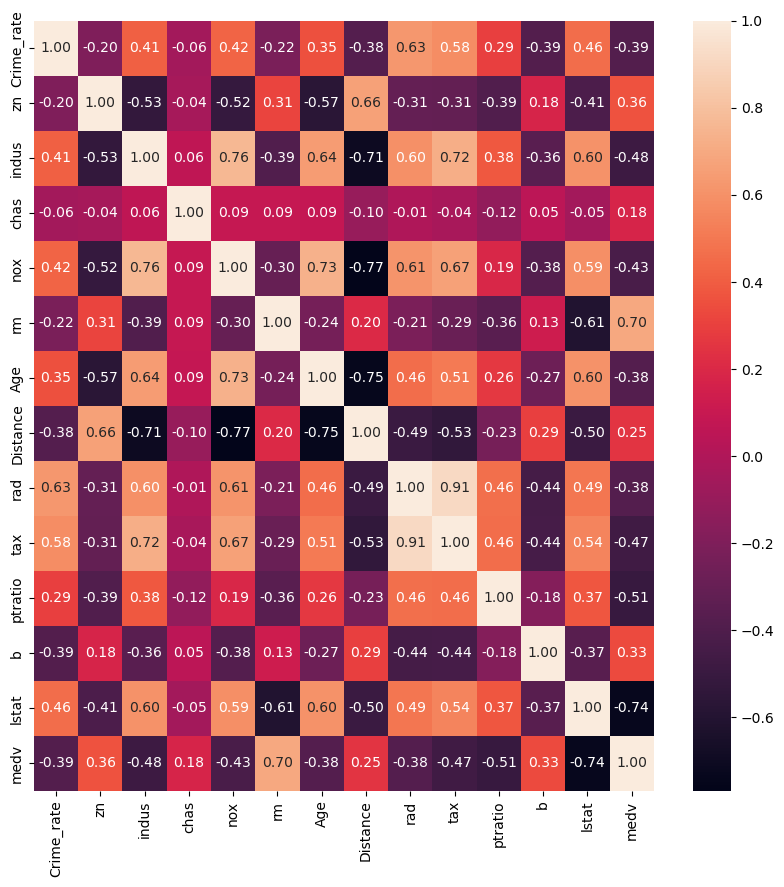

In [17]:
plt.figure(figsize=(10,10))
sns.heatmap(data=df.corr(), annot=True, fmt=".2f")
plt.show()

In [34]:
for col in ["Crime_rate","b","ptratio","rm","lstat"]:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR

    df[col] = df[col].clip(lower, upper)

#clip limits the values in the column
#Values below lower → set to lower
#Values above upper → set to upper
#This removes extreme values without dropping rows

In [19]:
num_cols = df.select_dtypes(include=np.number).columns

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    outliers = df[(df[col] < Q1 - 1.5*IQR) |
                  (df[col] > Q3 + 1.5*IQR)]

    print(col, "outliers:", len(outliers))

Crime_rate outliers: 0
zn outliers: 68
indus outliers: 0
chas outliers: 35
nox outliers: 0
rm outliers: 0
Age outliers: 0
Distance outliers: 5
rad outliers: 0
tax outliers: 0
ptratio outliers: 0
b outliers: 0
lstat outliers: 0
medv outliers: 40


In [31]:
for col in ["Crime_rate", "lstat", "tax", "Distance"]:
    df[col] = np.log1p(df[col])

In [21]:
df.drop(columns=["rad"], inplace=True)

In [22]:
X = df.drop("medv", axis=1)
y = df["medv"]

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42)

In [24]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [25]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [26]:
y_pred = model.predict(X_test)

In [29]:
print("R2 Score:", r2_score(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

R2 Score: 0.7438550086922548
RMSE: 4.235221611986041


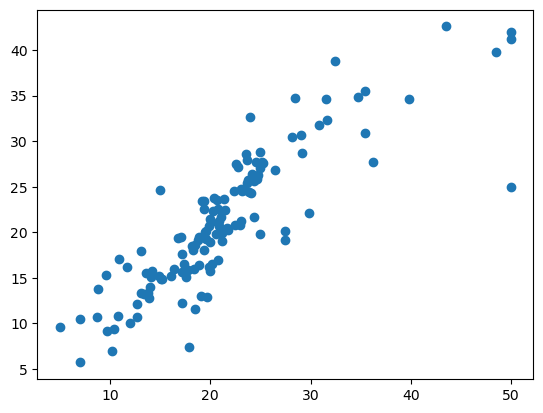

In [28]:
plt.scatter(y_test, y_pred)